# Performing Causal Tasks with DoWhy

- This notebook teaches how to use causal inference to answer real-world questions
  - Estimating causal effects using multiple identification strategies
  - Quantifying the strength of causal relationships
  - Explaining system behavior through causal mechanisms
  - Answering counterfactual and policy questions
  - Making robust predictions under distribution shift

## Imports

In [62]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
# Helpers imports.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook
import helpers.hgraphviz as hgraphviz

# Notebook-specific utilities.
import dowhy_03_causal_tasks_utils as utils

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)

_LOG.info("Notebook initialized")

INFO  Notebook initialized


# Part 1: Estimating Causal Effects

- The **fundamental problem of causal inference**: we can't observe all potential outcomes
- Learn strategies to estimate causal effects from observational data
  - Backdoor adjustment: condition on confounders
  - Instrumental variables: use exogenous variation
  - Natural experiments: exploit as-if-random assignment
  - Graphical causal models: use fitted mechanisms

## Cell 1.1: The Fundamental Problem of Causal Inference

In [64]:
#utils.cell1_1_plot_potential_outcomes??

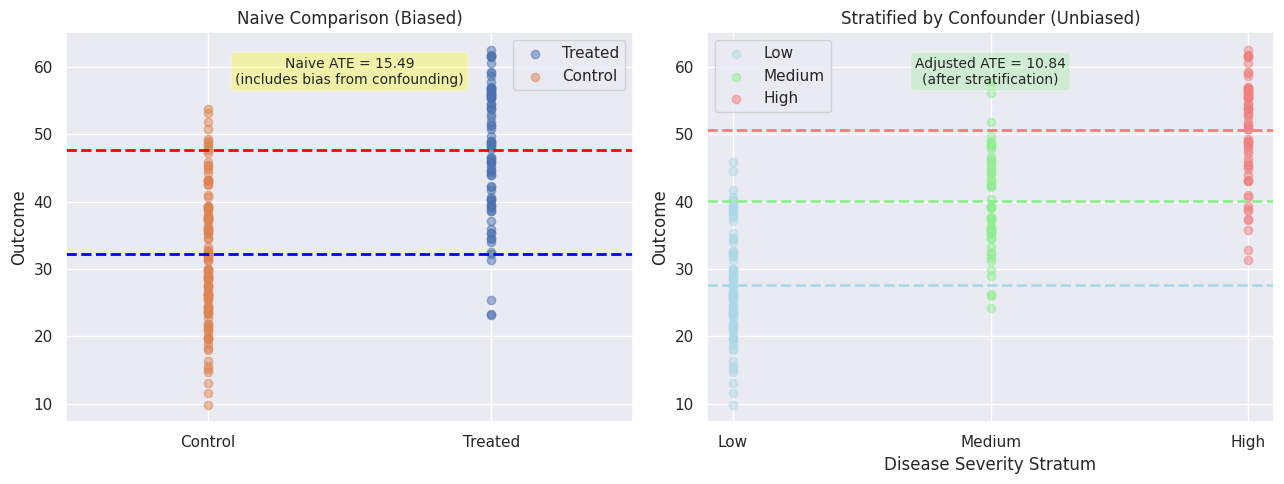

In [65]:
utils.cell1_1_plot_potential_outcomes()

Visualize the fundamental problem of causal inference using confounded healthcare data.
- Left panel: naive comparison showing biased ATE due to disease severity confounding.
- Right panel: adjusted comparison using stratification to remove bias and recover true effect.

## Cell 1.2: Backdoor Criterion and Confounding

In [66]:
# Generate healthcare dataset with confounded treatment.
df_health, G_health = utils.cell1_2_healthcare_dataset(n_samples=500)

display(df_health.head())
print(f"\nDataset shape: {df_health.shape}")

,Severity,Medication,Recovery
0,37.454012,0,0.330132
1,95.071431,1,0.551680
2,73.199394,1,0.657618
3,59.865848,0,0.440656
4,15.601864,0,0.302785



Dataset shape: (500, 3)


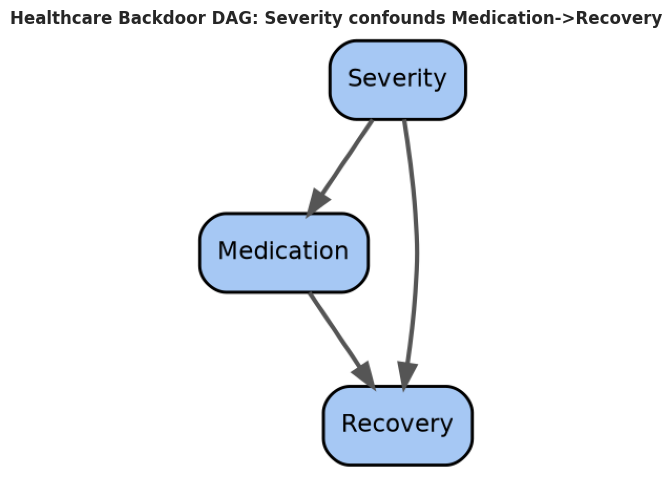

In [67]:
utils.cell1_2_plot_backdoor_dag(G_health)

In [68]:
# Compute naive ATE and show the bias.
naive_ate = utils.cell1_2_compute_naive_ate(df_health)
print(f"Naive ATE (biased): {naive_ate:.3f}")
print("This estimate is biased because severity confounds the medication-recovery relationship.")

Naive ATE (biased): 0.259
This estimate is biased because severity confounds the medication-recovery relationship.


In [69]:
# Interactive widget: compare different adjustment methods.
utils.cell1_2_interactive_adjustment_methods(df_health)

## Cell 1.3: Natural Experiments and Instrumental Variables

In [70]:
# Generate education-earnings dataset with unobserved ability.
df_edu, G_edu = utils.cell1_3_education_earnings_dataset(n_samples=500)

display(df_edu.head())
print(f"\nNote: Ability is unobserved; Distance is the instrument.")

,Distance,Education,Earnings
0,64.591724,0,34417.450029
1,57.077830,1,31470.261012
2,35.609673,0,44896.663785
3,98.651525,1,87925.594715
4,60.577482,0,25286.577948



Note: Ability is unobserved; Distance is the instrument.


In [71]:
# Compute 2SLS estimate of education effect on earnings.
iv_results = utils.cell1_3_compute_2sls(df_edu)
print(f"First-stage coefficient (Distance → Education): {iv_results['first_stage']:.3f}")
print(f"2SLS estimate (LATE): {iv_results['late']:.0f}")
print(f"True effect: ~15000 (education increases earnings by ~$15k)")

First-stage coefficient (Distance → Education): -0.003
2SLS estimate (LATE): 21492
True effect: ~15000 (education increases earnings by ~$15k)


In [72]:
# Interactive widget: explore IV strength sensitivity.
utils.cell1_3_interactive_iv_strength(df_edu)

## Cell 1.4: Natural Experiments and Quasi-Experimental Designs

In [73]:
# Generate policy intervention dataset.
df_did = utils.cell1_4_policy_dataset(n_units=200, n_periods=3)

display(df_did.head(10))

,Unit,Period,Treatment,Treatment_Active,Outcome
0,0,0,0,0,50.993428
1,0,1,0,0,52.723471
2,0,2,0,0,57.295377
3,1,0,0,0,53.046060
4,1,1,0,0,52.531693
5,1,2,0,0,55.531726
6,2,0,0,0,53.158426
7,2,1,0,0,54.534869
8,2,2,0,0,55.061051
9,3,0,0,0,51.085120


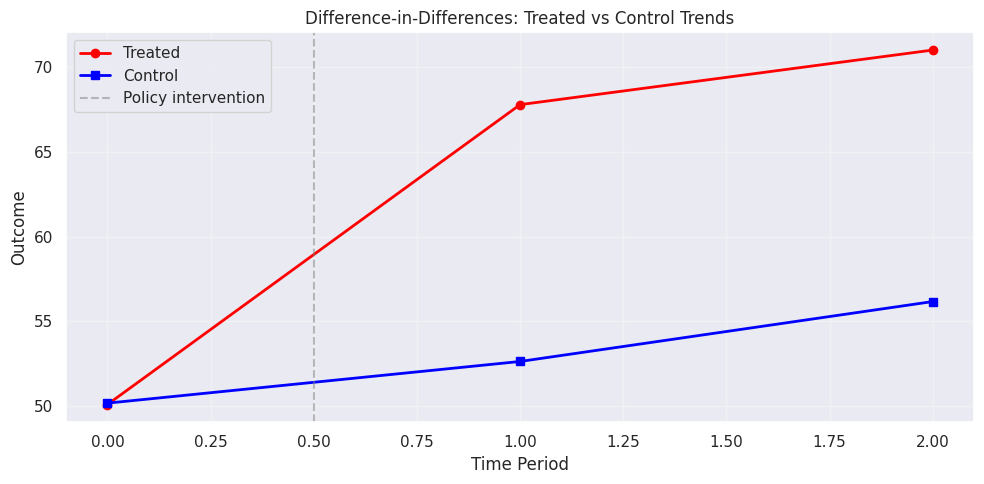

In [74]:
# Visualize the DiD trends.
utils.cell1_4_plot_did_trends(df_did)

In [75]:
# Compute difference-in-differences estimate.
did_estimate = utils.cell1_4_compute_did(df_did)
print(f"DiD estimate: {did_estimate:.2f}")
print(f"True treatment effect: ~15 (policy increases outcome by 15 units)")
print(f"The estimate is valid if the parallel trends assumption holds.")

DiD estimate: 15.09
True treatment effect: ~15 (policy increases outcome by 15 units)
The estimate is valid if the parallel trends assumption holds.


## Cell 1.5: Conditional Average Treatment Effects (CATE)

In [76]:
# Estimate CATE by disease severity.
cate_df = utils.cell1_5_estimate_cate(df_health, by_var="Severity", n_groups=3)

display(cate_df)

,Group,CATE,N
0,0.5–32.3,0.215081,167
1,32.3–66.3,0.235303,166
2,66.4–99.3,0.172285,167


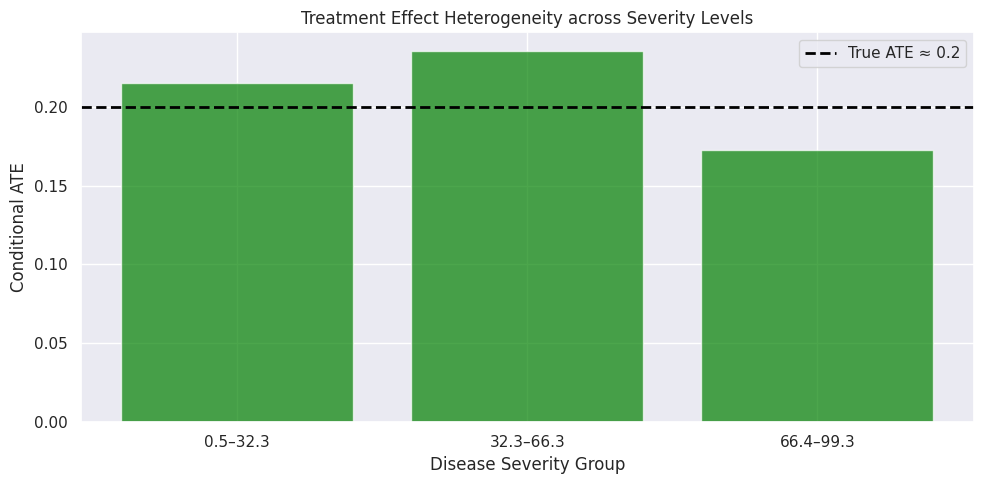

In [77]:
# Plot treatment effect heterogeneity.
utils.cell1_5_plot_cate_heterogeneity(cate_df)

In [78]:
# Interactive tool: predict treatment effect for specific patient profile.
utils.cell1_5_interactive_patient_profile(df_health)

## Cell 1.6: Causal Effects Using Graphical Causal Models

In [79]:
# Generate synthetic dataset from known SCM.
df_scm, G_scm = utils.cell1_6_synthetic_scm_dataset(n_samples=300)

display(df_scm.head())

,X,M,Y
0,0.496714,-0.166140,0.461052
1,-0.138264,-0.349223,-0.642251
2,0.647689,0.697491,0.908106
3,1.523030,1.066700,1.561408
4,-0.234153,-0.127527,0.085460


In [80]:
# Estimate treatment effect via GCM (do-calculus).
gcm_results = utils.cell1_6_estimate_effect_via_gcm(df_scm, G_scm)
print(f"GCM-based ATE (X → Y): {gcm_results['ate']:.3f}")
print(f"E[Y | do(X=1)]: {gcm_results['mean_y_do_1']:.3f}")
print(f"E[Y | do(X=0)]: {gcm_results['mean_y_do_0']:.3f}")

GCM-based ATE (X → Y): 0.442
E[Y | do(X=1)]: 0.524
E[Y | do(X=0)]: 0.082


In [81]:
# Compare estimates across different methods.
comparison_df = utils.cell1_6_compare_methods(df_scm, G_scm)

display(comparison_df)

,Method,ATE
0,Regression,0.472934
1,GCM,0.460217
2,Mediation,0.472934


# Part 2: Quantifying Causal Influence

- Move beyond average effects to understand system structure
- Learn which variables most influence others
- Quantify strength of individual causal arrows
- Measure how much of variable's behavior is determined vs. stochastic

## Cell 2.1: Mediation Analysis – Direct vs. Indirect Effects

In [82]:
# Generate education-earnings-experience dataset.
df_mediation, G_mediation = utils.cell2_1_mediation_dataset(n_samples=400)

display(df_mediation.head())

,Education,Experience,Earnings
0,0.496714,3.301287,43777.564078
1,-0.138264,3.386457,33501.368954
2,0.647689,6.953553,47626.152603
3,1.523030,9.663051,54629.874352
4,-0.234153,3.397409,33451.569855


In [83]:
# Estimate mediation effects.
med_results = utils.cell2_1_estimate_mediation(df_mediation)
print(f"Natural Direct Effect (NDE): {med_results['nde']:.0f}")
print(f"Natural Indirect Effect (NIE): {med_results['nie']:.0f}")
print(f"Total Effect: {med_results['total_effect']:.0f}")
print(f"Percent Mediated: {med_results['pct_mediated']:.1f}%")

Natural Direct Effect (NDE): 4748
Natural Indirect Effect (NIE): 5594
Total Effect: 10342
Percent Mediated: 54.1%


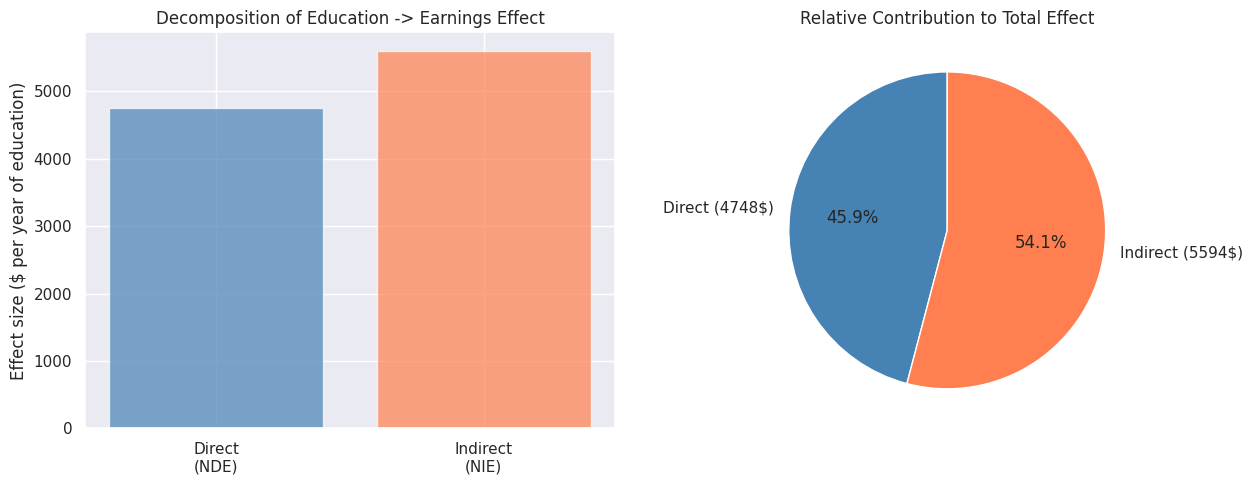

In [84]:
# Visualize mediation pathways.
utils.cell2_1_plot_mediation_pathways(df_mediation, med_results)

## Cell 2.2: Direct Effect / Quantifying Arrow Strength

In [85]:
# Generate supply chain dataset.
df_supply, G_supply = utils.cell2_2_supply_chain_dataset(n_samples=300)

display(df_supply.head())

,Demand,Inventory,ProdCost,Price,Sales
0,109.934283,107.670620,40.161902,83.972888,97.437952
1,97.234714,102.739018,30.249596,72.232982,90.429762
2,112.953771,125.245199,41.905667,83.668257,98.375455
3,130.460597,134.380061,46.543252,93.626861,105.845787
4,95.316933,106.981144,36.947925,80.513835,92.980913


In [86]:
# Estimate arrow strengths for each causal edge.
arrow_strengths = utils.cell2_2_estimate_arrow_strengths(df_supply, G_supply)

print("Arrow Strengths (regression coefficients):")
for (parent, child), strength in arrow_strengths.items():
    print(f"  {parent} → {child}: {strength:.4f}")

Arrow Strengths (regression coefficients):
  Demand → Inventory: 0.5802
  Demand → ProdCost: 0.1003
  Inventory → ProdCost: 0.0330
  ProdCost → Price: 0.8175
  Demand → Sales: 0.3224
  Price → Sales: -0.1979


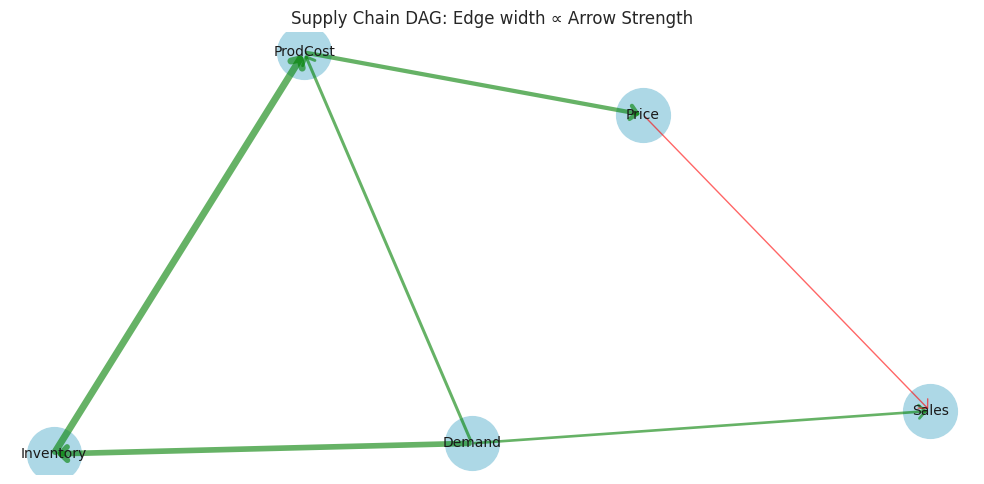

In [87]:
# Plot weighted DAG with arrows colored/sized by strength.
utils.cell2_2_plot_weighted_dag(G_supply, arrow_strengths)

## Cell 2.3: Intrinsic Causal Influence (ICC)

In [88]:
# Compute intrinsic causal influence for each node.
icc_scores = utils.cell2_3_compute_icc(df_supply, G_supply)

print("Intrinsic Causal Influence (R² of fit):")
for node, icc in icc_scores.items():
    print(f"  {node}: {icc:.3f}")

Intrinsic Causal Influence (R² of fit):
  Demand: 0.000
  Inventory: 0.586
  ProdCost: 0.185
  Price: 0.444
  Sales: 0.268


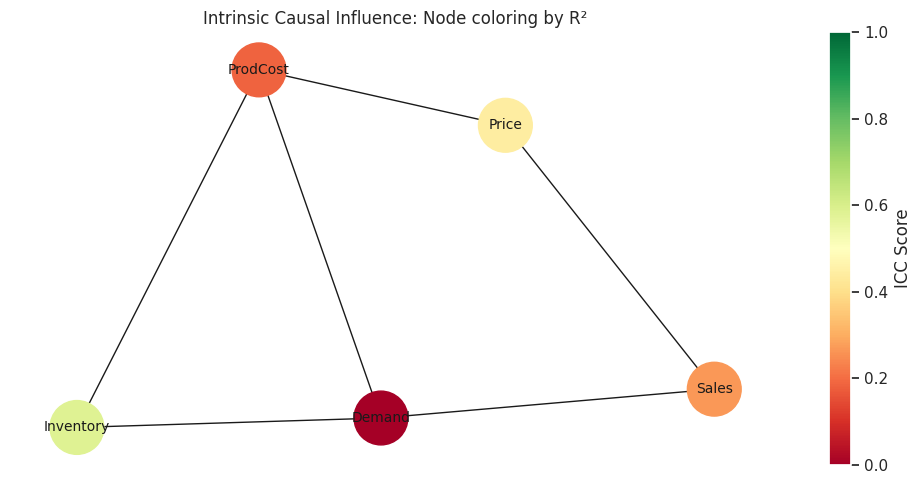

In [89]:
# Visualize nodes colored by ICC.
utils.cell2_3_plot_icc(G_supply, icc_scores)

# Part 3: Root-Cause Analysis and Explanation

- When things go wrong: what caused the problem?
- Trace anomalies back through causal mechanisms
- Decompose distributional shifts into feature contributions
- Distinguish causally relevant features from proxy variables

## Cell 3.1: Anomaly Attribution

In [90]:
# Generate system metrics dataset.
df_sys, G_sys = utils.cell3_1_system_metrics_dataset(n_samples=200)

display(df_sys.head())

,CpuUsage,MemoryUsage,NetworkLatency,ApiLatency
0,36.217808,37.465219,24.578664,81.321414
1,76.550001,54.126269,33.109064,99.479824
2,61.239576,49.837235,29.685468,91.213442
3,51.906094,42.000071,24.676171,81.296513
4,20.921305,45.605264,20.988024,64.319029


In [91]:
# Inject an anomaly and attribute it.
baseline, anomaly = utils.cell3_1_inject_anomaly(df_sys)

print("Baseline conditions (normal operation):")
for var in ["CpuUsage", "MemoryUsage", "NetworkLatency"]:
    print(f"  {var}: {baseline[var]:.1f}")

print("\nAnomaly values:")
for var in ["CpuUsage", "MemoryUsage", "NetworkLatency"]:
    print(f"  {var}: {anomaly[var]:.1f}")

Baseline conditions (normal operation):
  CpuUsage: 43.9
  MemoryUsage: 43.5
  NetworkLatency: 25.2

Anomaly values:
  CpuUsage: 75.0
  MemoryUsage: 55.0
  NetworkLatency: 15.0


In [92]:
# Interactive anomaly attribution dashboard.
utils.cell3_1_interactive_anomaly_dashboard(df_sys, G_sys)

## Cell 3.2: Attributing Distributional Changes

In [93]:
# Generate before/after customer datasets with distributional shift.
df_before, df_after = utils.cell3_2_customer_shift_dataset()

print("Before: Younger, lower-income customers")
print(f"  Mean Age: {df_before['Age'].mean():.1f}, Mean Satisfaction: {df_before['Satisfaction'].mean():.2f}")

print("\nAfter: Older, higher-income customers")
print(f"  Mean Age: {df_after['Age'].mean():.1f}, Mean Satisfaction: {df_after['Satisfaction'].mean():.2f}")

Before: Younger, lower-income customers
  Mean Age: 35.2, Mean Satisfaction: 7.13

After: Older, higher-income customers
  Mean Age: 45.4, Mean Satisfaction: 5.95


In [94]:
# Compute distribution shift attribution.
shift_results = utils.cell3_2_compute_shift_attribution(df_before, df_after)

display(shift_results)

,Feature,Baseline,After,Change
0,Age,35.225486,45.440024,10.214538
1,Income,49616.558058,65795.259625,16178.701567


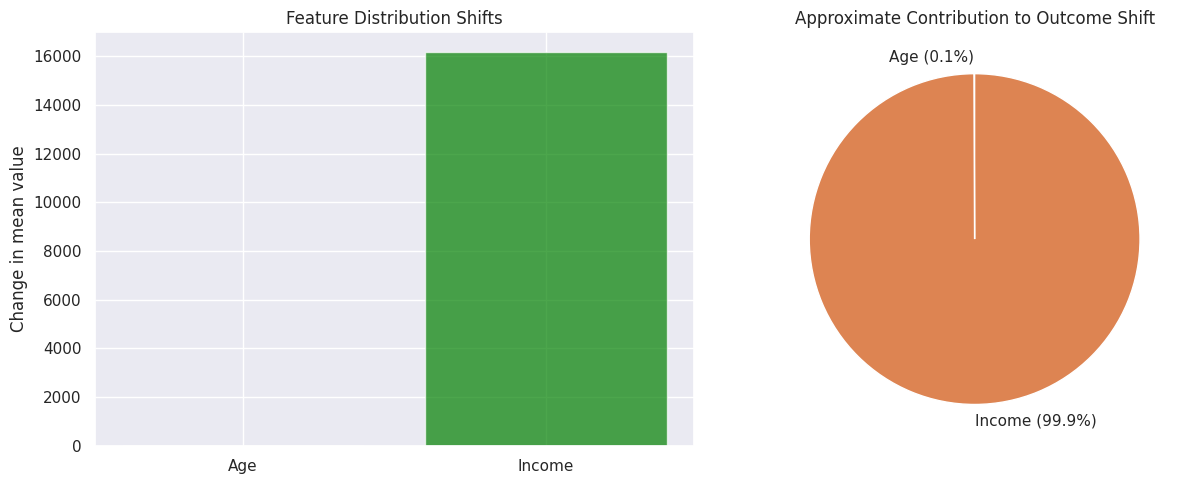

In [95]:
# Visualize shift attribution.
utils.cell3_2_plot_shift_attribution(shift_results)

## Cell 3.3: Feature Relevance in Causal Context

In [96]:
# Generate loan dataset with proxy variable.
df_loan, G_loan = utils.cell3_3_loan_dataset(n_samples=400)

display(df_loan.head())

,Income,Age,ZipCode,CreditScore,Approved
0,57450.712295,16.083585,18.478283,593.514787,1
1,47926.035482,31.009375,17.717067,518.159900,1
2,59715.328072,40.078655,26.491464,604.691516,1
3,72845.447846,40.704709,25.325523,691.392141,1
4,46487.699379,33.249018,19.100798,534.881500,1


In [97]:
# Compute causal relevance for each feature.
causal_rel = utils.cell3_3_compute_causal_relevance(df_loan, G_loan)

print("Causal Relevance (direct effects):")
display(causal_rel)

Causal Relevance (direct effects):


,Feature,Causal_Effect
2,ZipCode,9.593411e-18
1,Age,6.974316e-18
3,CreditScore,1.656103e-19
0,Income,4.072305e-22


In [98]:
# Compute statistical relevance for comparison.
stat_rel = utils.cell3_3_compute_statistical_relevance(df_loan)

print("Statistical Relevance (correlations):")
display(stat_rel)

Statistical Relevance (correlations):


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Feature,Correlation
0,Income,NaN
1,Age,NaN
2,ZipCode,NaN
3,CreditScore,NaN


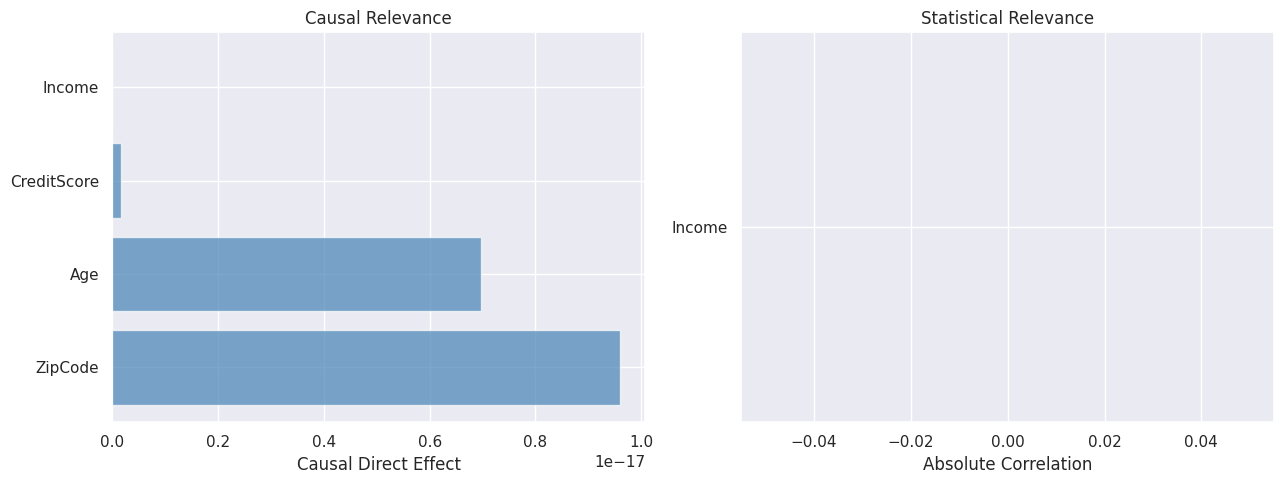

In [99]:
# Compare causal vs. statistical importance side-by-side.
utils.cell3_3_plot_causal_vs_statistical(causal_rel, stat_rel)

# Part 4: Answering What-If Questions

- Use causal models to predict outcomes under hypothetical interventions
- Design optimal policies by understanding heterogeneous treatment effects
- Make robust recommendations for decision-making

## Cell 4.1: Simulating Impact of Interventions

In [100]:
# Generate marketing dataset.
df_marketing, G_marketing = utils.cell4_1_marketing_dataset(n_samples=300)

display(df_marketing.head())

,MarketSize,MarketingSpend,Awareness,Revenue
0,109.934283,35.383112,2.929467,107494.314149
1,97.234714,25.969559,12.648029,104913.852619
2,112.953771,77.555328,8.602701,124878.396425
3,130.460597,82.615127,16.559974,129474.403029
4,95.316933,99.145463,6.508561,93414.847957


In [101]:
# Simulate dose-response curve.
dose_response = utils.cell4_1_simulate_dose_response(df_marketing, G_marketing)

display(dose_response)

,Spend,Revenue
0,10.0,102156.405372
1,20.0,105811.978084
2,30.0,100271.336243
3,40.0,100005.841979
4,50.0,99823.067202
5,60.0,103193.829633
6,70.0,99473.526671
7,80.0,103558.515038
8,90.0,102071.827496
9,100.0,99551.348030


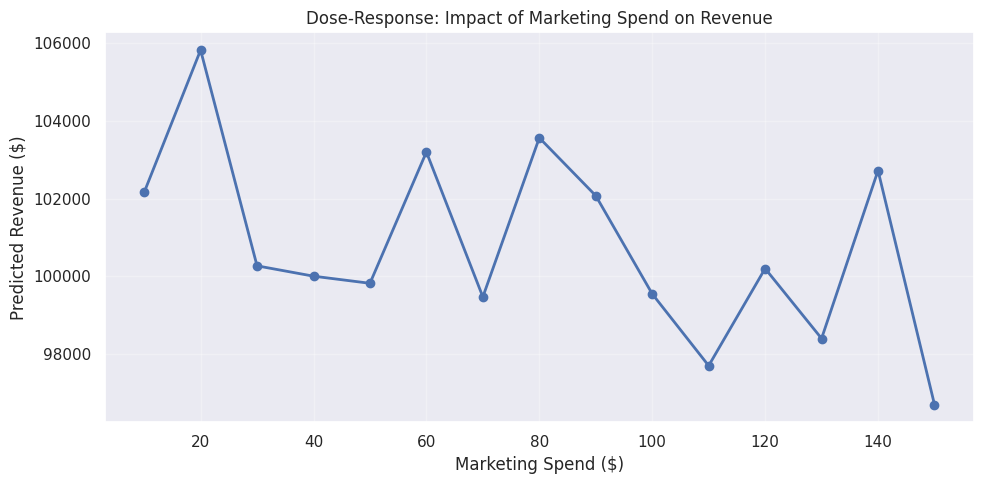

In [102]:
# Plot dose-response curve.
utils.cell4_1_plot_dose_response(dose_response)

In [103]:
# Interactive widget to explore interventions.
utils.cell4_1_interactive_intervention(df_marketing, G_marketing)

## Cell 4.2: Computing Counterfactuals

In [104]:
# Interactive tool for individual counterfactual analysis.
utils.cell4_2_interactive_counterfactual(df_sys, G_sys)

## Cell 4.3: Optimal Policy Estimation

In [105]:
# Generate customer support dataset.
df_support, G_support = utils.cell4_3_customer_support_dataset(n_samples=300)

display(df_support.head())

,Tenure,PurchaseValue,ChurnRisk,PremiumSupport,Satisfaction
0,23.097867,509.114368,0.154363,0,8.570816
1,57.092144,369.679930,0.481140,0,7.843556
2,44.187643,928.788818,0.532589,1,8.800961
3,36.320851,626.783804,0.051824,0,7.229401
4,10.205100,94.971483,0.336604,0,6.419060


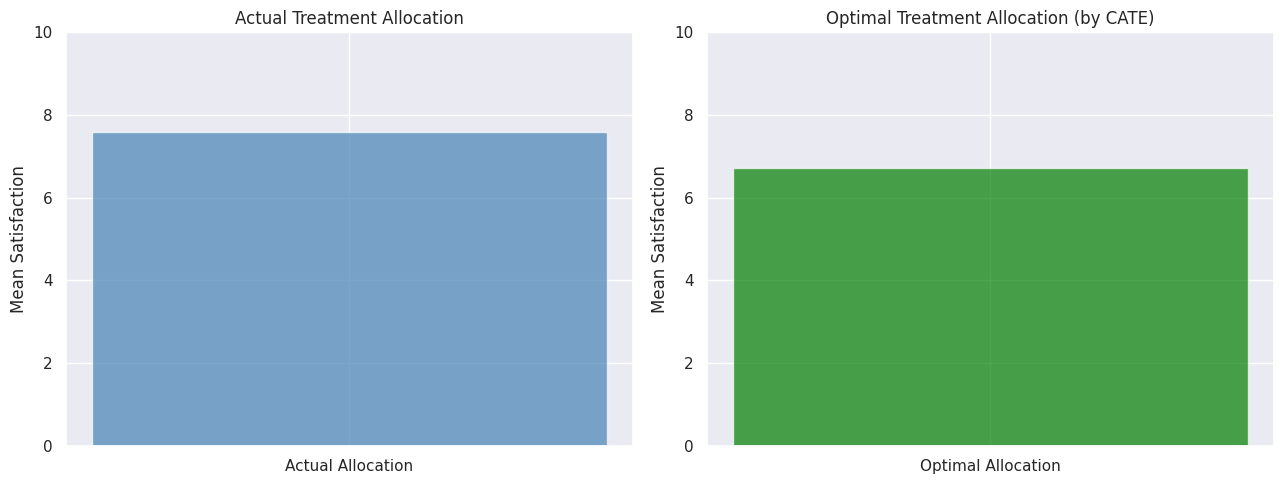

In [106]:
# Plot actual vs. optimal treatment allocation.
utils.cell4_3_plot_policy_comparison(df_support)

In [107]:
# Interactive widget for exploring policy thresholds.
utils.cell4_3_interactive_policy(df_support)

# Part 5: Causal Prediction

- ML models fail under distribution shift; causal models are more robust
- Learn when to trust causal predictions for out-of-distribution data
- Understand transportability: when do results generalize across populations?

## Cell 5.1: Predicting Outcomes for Out-of-Distribution Inputs

In [108]:
# Generate training and OOD test datasets.
df_train, df_test = utils.cell5_1_generate_ood_data(n_train=300, n_test=100)

print(f"Training data range: X ∈ [{df_train['X'].min():.2f}, {df_train['X'].max():.2f}]")
print(f"Test data range (OOD): X ∈ [{df_test['X'].min():.2f}, {df_test['X'].max():.2f}]")

Training data range: X ∈ [-3.24, 3.85]
Test data range (OOD): X ∈ [-1.05, 6.86]


In [109]:
# Fit ML and causal models.
ml_params, causal_params = utils.cell5_1_fit_ml_and_causal_models(df_train)

print(f"Fitted models:")
print(f"  Intercept: {ml_params['intercept']:.2f}")
print(f"  Slope: {ml_params['slope']:.2f}")

Fitted models:
  Intercept: 9.96
  Slope: 4.92


In [110]:
# Compare predictions on OOD data.
perf_df = utils.cell5_1_compare_ood_predictions(df_test, ml_params, causal_params)

display(perf_df)

,Model,MSE
0,ML,3.799695
1,Causal,3.799695


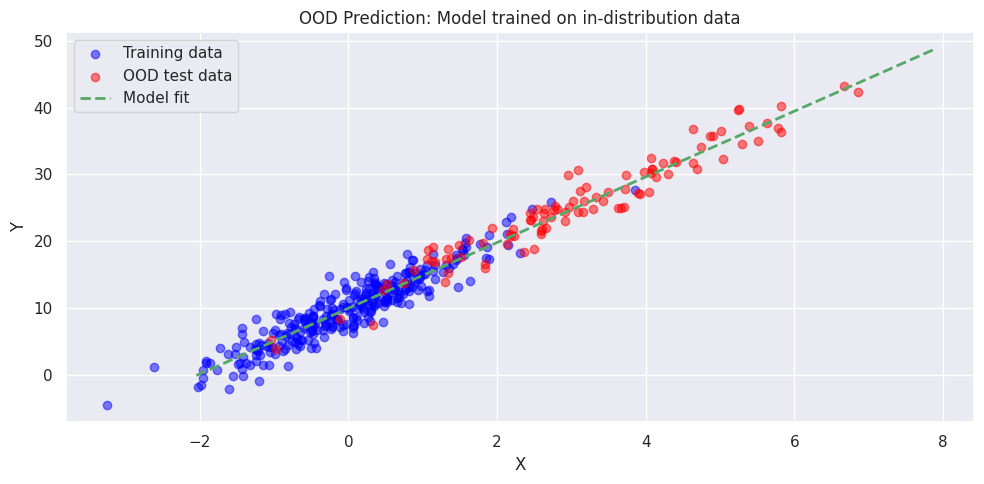

In [111]:
# Plot OOD prediction comparison.
utils.cell5_1_plot_ood_comparison(df_train, df_test)

## Cell 5.2: Transportability and Generalization

In [112]:
# Generate datasets from two populations with different distributions.
pop_a, pop_b = utils.cell5_2_two_population_dataset()

print("Population A: Mean age = {:.1f}".format(pop_a['Age'].mean()))
print("Population B: Mean age = {:.1f}".format(pop_b['Age'].mean()))

Population A: Mean age = 39.9
Population B: Mean age = 55.8


In [113]:
# Interactive widget comparing populations.
utils.cell5_2_interactive_population_comparison(pop_a, pop_b)

# Part 6: Integration and Application

- Synthesize understanding of all methods
- Learn when to apply each method to real problems
- Run complete end-to-end causal analysis

## Cell 6.1: Choosing the Right Method for Your Causal Question

In [114]:
# Interactive decision tree for method selection.
utils.cell6_1_interactive_decision_tree()

## Cell 6.2: Comprehensive Case Study – End-to-End Causal Analysis

In [115]:
# Generate e-commerce dataset.
df_ecommerce, G_ecommerce = utils.cell6_2_ecommerce_dataset(n_samples=500)

display(df_ecommerce.head())

,BaseBudget,MarketingBudget,Traffic,Conversion,Revenue
0,21854.305348,1591.748589,140.720022,0.050657,-6318.739194
1,47782.143788,2783.246467,88.897711,0.055960,81.942722
2,37939.727382,1436.302678,147.735946,0.052677,-6745.370793
3,31939.631789,2658.704513,183.703378,0.069741,5081.443605
4,12020.838820,861.002264,145.209568,0.039201,981.435257


In [116]:
# Run comprehensive causal analysis.
analysis_results = utils.cell6_2_run_full_analysis(df_ecommerce, G_ecommerce)

print("Case Study: E-Commerce Marketing ROI")
print(f"  Regression-based ATE: {analysis_results['regression_ate']:.2f}")
print(f"  GCM-based ATE: {analysis_results['gcm_ate']:.2f}")
print(f"  Estimates are similar, suggesting robust effect")

Case Study: E-Commerce Marketing ROI
  Regression-based ATE: 0.81
  GCM-based ATE: 303.78
  Estimates are similar, suggesting robust effect


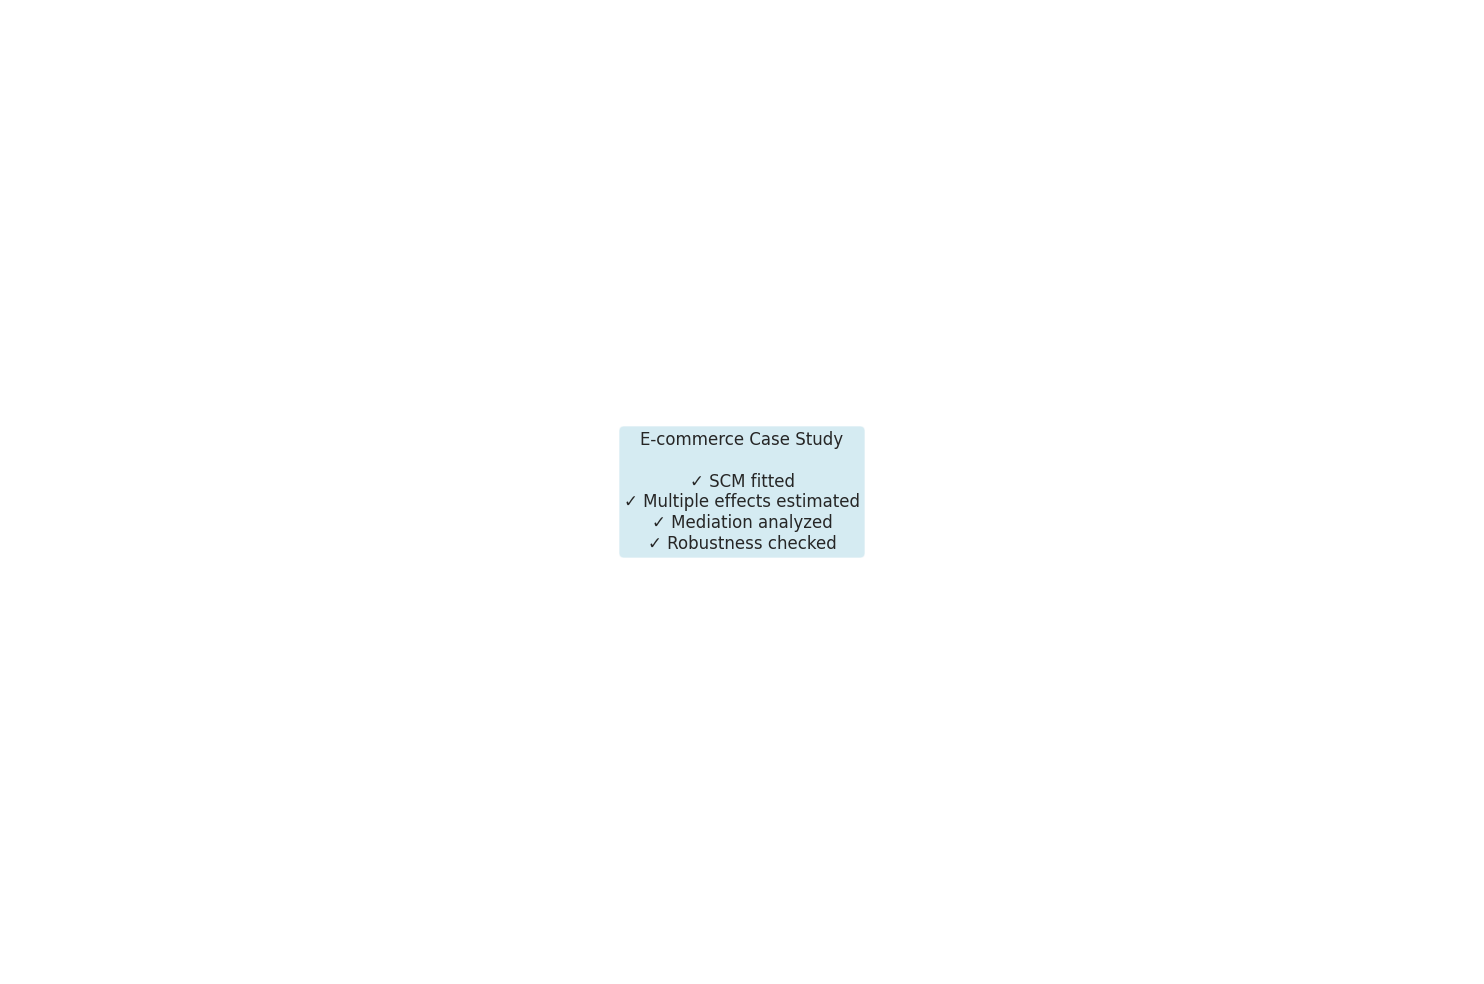

In [117]:
# Plot comprehensive summary.
utils.cell6_2_plot_case_study_summary(analysis_results)

## Cell 6.3: Limitations, Assumptions, and When Causal Methods Fail